In [4]:
install.packages("forecast")
install.packages("ggplot2")
install.packages("dplyr")
install.packages("readr")

library(forecast)
library(ggplot2)
library(dplyr)
library(readr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [5]:
jembe_raw     <- read_csv("jembe.csv")
ngelehun_raw  <- read_csv("Ngelehun.csv")


Rows: 24 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): periodname
dbl (16): periodid, periodcode, All other referrals, Anaemia referrals, Burn...
lgl (17): perioddescription, Acute Flaccid Paralysis (AFP) referrals, Diarrh...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 24 Columns: 34
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (1): periodname
dbl (30): periodid, periodcode, Acute Flaccid Paralysis (AFP) referrals, All...
lgl  (3): perioddescription, PLHIVs referred for TB screening, PLHIVs referr...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
###############################################
# 2. Build total_referrals per month per facility
###############################################

# Columns that are NOT referral indicators in the raw CSVs
# (facility is NOT here because it doesn't exist yet in jembe_raw)
ignore_cols <- c("periodid", "periodname", "periodcode", "perioddescription")

# Identify numeric referral indicator columns from Jembe once
referral_cols <- jembe_raw %>%
  select(-any_of(ignore_cols)) %>%   # drop metadata if present
  select(where(is.numeric)) %>%      # keep only numeric indicator columns
  names()

# Jembe CHC
jembe <- jembe_raw %>%
  mutate(facility = "Jembe CHC") %>%
  mutate(
    total_referrals = rowSums(across(all_of(referral_cols)), na.rm = TRUE)
  )

# Ngelehun CHC
ngelehun <- ngelehun_raw %>%
  mutate(facility = "Ngelehun CHC") %>%
  mutate(
    total_referrals = rowSums(across(all_of(referral_cols)), na.rm = TRUE)
  )


In [10]:
referrals_df <- dplyr::bind_rows(jembe, ngelehun) %>%
  dplyr::mutate(
    date = as.Date(paste0(periodcode, "01"), format = "%Y%m%d")
  ) %>%
  dplyr::arrange(facility, date)


In [11]:
ts_df <- referrals_df %>%
  dplyr::select(facility, date, total_referrals) %>%
  dplyr::arrange(facility, date)

# Jembe CHC series
jembe_vec <- ts_df %>%
  dplyr::filter(facility == "Jembe CHC") %>%
  dplyr::pull(total_referrals)

jembe_ts <- ts(jembe_vec, frequency = 12)

# Ngelehun CHC series
ng_vec <- ts_df %>%
  dplyr::filter(facility == "Ngelehun CHC") %>%
  dplyr::pull(total_referrals)

ng_ts <- ts(ng_vec, frequency = 12)

In [12]:
ts_metrics <- function(actual, pred) {
  # convert ts -> numeric
  actual <- as.numeric(actual)
  pred   <- as.numeric(pred)

  # align lengths
  n <- min(length(actual), length(pred))
  actual <- actual[1:n]
  pred   <- pred[1:n]

  # drop NA pairs
  ok <- !(is.na(actual) | is.na(pred))
  actual <- actual[ok]
  pred   <- pred[ok]

  # if nothing left, return NAs
  if (length(actual) == 0) {
    return(data.frame(MAE = NA, RMSE = NA, MAPE = NA, R2 = NA))
  }

  mae  <- mean(abs(actual - pred))
  rmse <- sqrt(mean((actual - pred)^2))

  # avoid div-by-zero in MAPE
  denom <- ifelse(actual == 0, NA, actual)
  mape <- mean(abs((actual - pred) / denom) * 100, na.rm = TRUE)

  # R² (guard constant series)
  if (var(actual) == 0) {
    r2 <- NA
  } else {
    r2 <- 1 - sum((actual - pred)^2) / sum((actual - mean(actual))^2)
  }

  data.frame(MAE = mae, RMSE = rmse, MAPE = mape, R2 = r2)
}


In [13]:
fit_and_forecast <- function(series, h_test = 6, h_future = 12) {
  n <- length(series)

  # ensure test window isn't too big
  h_test <- min(h_test, max(1, n - 5))  # keep at least 5 points for training

  train <- ts(series[1:(n - h_test)], frequency = 12)
  test  <- ts(series[(n - h_test + 1):n], frequency = 12)

  # Fit models
  ets_fit   <- ets(train)
  arima_fit <- auto.arima(train, seasonal = TRUE)

  # Forecast for test period
  ets_fc_test   <- forecast(ets_fit,   h = h_test)
  arima_fc_test <- forecast(arima_fit, h = h_test)

  # Validation metrics
  ets_metrics   <- ts_metrics(test, ets_fc_test$mean)
  arima_metrics <- ts_metrics(test, arima_fc_test$mean)

  ets_metrics$model   <- "ETS"
  arima_metrics$model <- "ARIMA"

  val_results <- rbind(ets_metrics, arima_metrics)

  # Refit on full data
  ets_full   <- ets(series)
  arima_full <- auto.arima(series, seasonal = TRUE)

  # Forecast next 12 months
  ets_future   <- forecast(ets_full,   h = h_future)
  arima_future <- forecast(arima_full, h = h_future)

  list(
    val_results   = val_results,
    ets_future    = ets_future,
    arima_future  = arima_future
  )
}



In [14]:
jembe_models <- fit_and_forecast(jembe_ts)
ng_models    <- fit_and_forecast(ng_ts)

In [15]:
cat("=== Validation – Jembe CHC ===\n")
print(jembe_models$val_results)

cat("\n=== Validation – Ngelehun CHC ===\n")
print(ng_models$val_results)


=== Validation – Jembe CHC ===
       MAE     RMSE     MAPE         R2 model
1 13.16667 17.12871 19.97315 -0.1713576   ETS
2 13.16667 17.13031 19.97155 -0.1715771 ARIMA

=== Validation – Ngelehun CHC ===
       MAE     RMSE     MAPE         R2 model
1 11.96367 18.94529 48.64533 -0.1892554   ETS
2 11.83333 18.27339 44.66575 -0.1063967 ARIMA


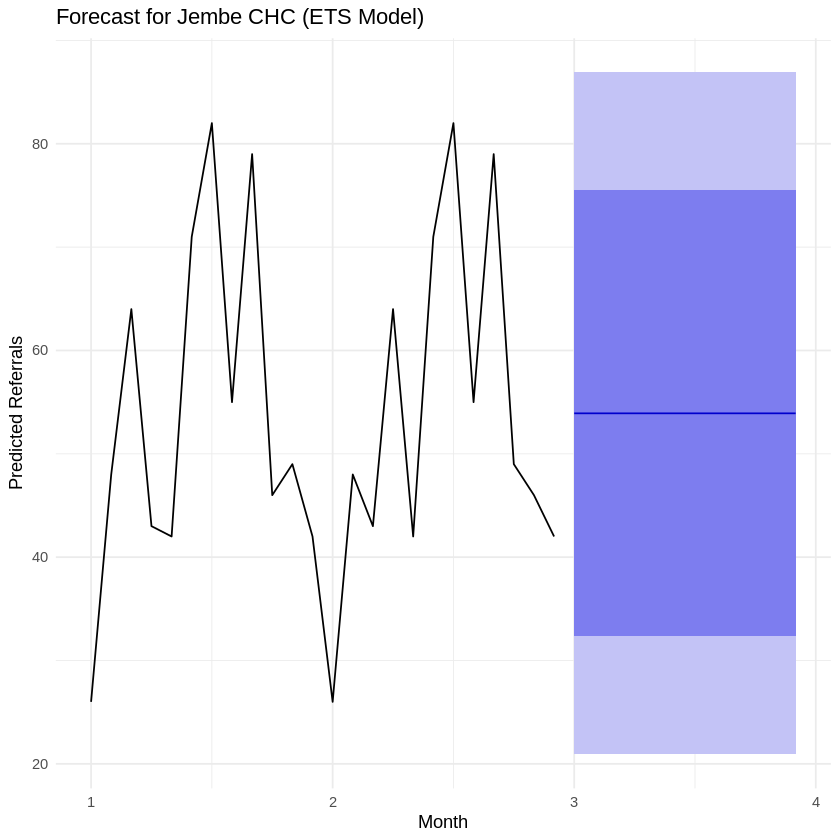

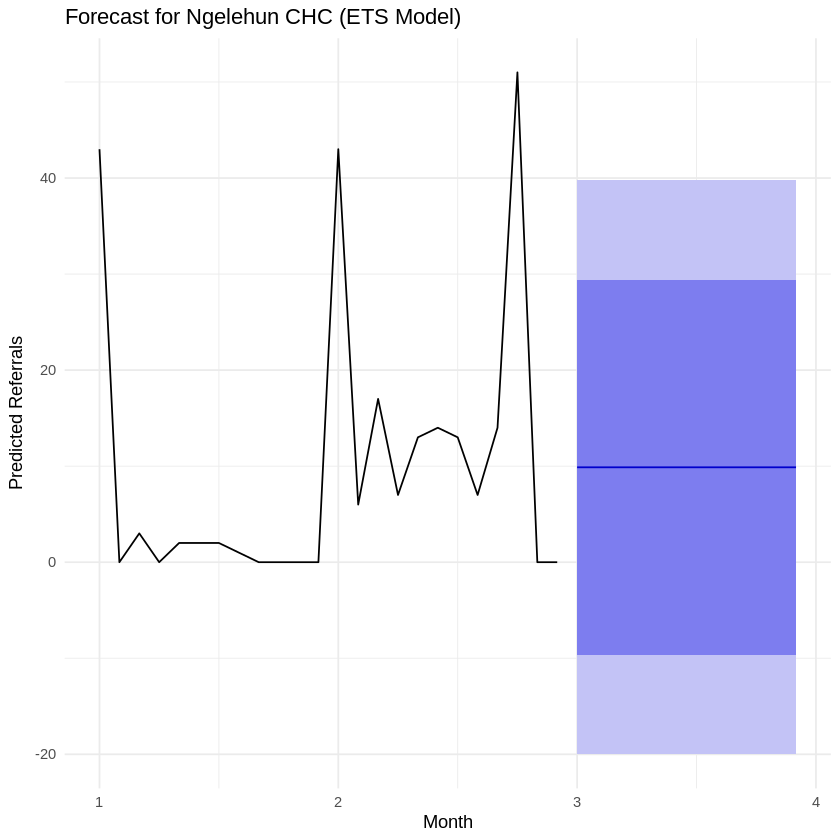

In [16]:
autoplot(jembe_models$ets_future) +
  ggtitle("Forecast for Jembe CHC (ETS Model)") +
  xlab("Month") +
  ylab("Predicted Referrals") +
  theme_minimal()

autoplot(ng_models$ets_future) +
  ggtitle("Forecast for Ngelehun CHC (ETS Model)") +
  xlab("Month") +
  ylab("Predicted Referrals") +
  theme_minimal()



In [17]:
jembe_forecast_table <- as.data.frame(jembe_models$ets_future)
jembe_forecast_table$facility <- "Jembe CHC"

# Ngelehun
ng_forecast_table <- as.data.frame(ng_models$ets_future)
ng_forecast_table$facility <- "Ngelehun CHC"

# Combined table
combined_forecast <- dplyr::bind_rows(jembe_forecast_table, ng_forecast_table)

cat("\n=== Combined Forecast Table (Next 12 Months) ===\n")
print(combined_forecast)



=== Combined Forecast Table (Next 12 Months) ===
           Point Forecast     Lo 80    Hi 80     Lo 95    Hi 95     facility
Jan 3...1       53.916829 32.343158 75.49050  20.92275 86.91091    Jembe CHC
Feb 3...2       53.916829 32.343158 75.49050  20.92275 86.91091    Jembe CHC
Mar 3...3       53.916829 32.343158 75.49050  20.92275 86.91091    Jembe CHC
Apr 3...4       53.916829 32.343158 75.49050  20.92275 86.91091    Jembe CHC
May 3...5       53.916829 32.343157 75.49050  20.92275 86.91091    Jembe CHC
Jun 3...6       53.916829 32.343157 75.49050  20.92275 86.91091    Jembe CHC
Jul 3...7       53.916829 32.343157 75.49050  20.92275 86.91091    Jembe CHC
Aug 3...8       53.916829 32.343157 75.49050  20.92274 86.91091    Jembe CHC
Sep 3...9       53.916829 32.343157 75.49050  20.92274 86.91091    Jembe CHC
Oct 3...10      53.916829 32.343157 75.49050  20.92274 86.91091    Jembe CHC
Nov 3...11      53.916829 32.343157 75.49050  20.92274 86.91091    Jembe CHC
Dec 3...12      53.916829 